<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


#### Install the required libraries and import them


In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Connect to the SQLite database


In [2]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [4]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
df

,COUNT(*)
0,65437


**Demo 2: List all tables**


In [5]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [6]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [14]:
## Write your code here
QUERY = "select CompTotal from main"
df_comp_total = pd.read_sql(QUERY, conn)

df_comp_total['CompTotal'].unique()

array([     nan, 2040000.,   28000., ...,  254600.,  247433.,   77700.],
      shape=(3338,))

Text(0.5, 1.0, "Distribution of Respondents' Total Compensation")

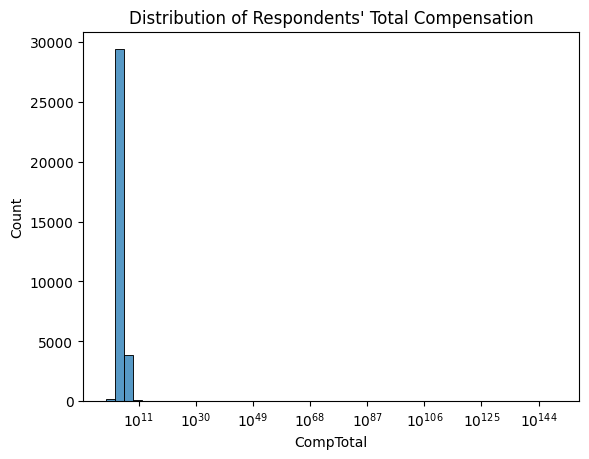

In [34]:
sns.histplot(data=df_comp_total['CompTotal'].dropna(), bins=50, log_scale=True)
plt.title("Distribution of Respondents' Total Compensation")

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [31]:
## Write your code here
QUERY = "Select YearsCodePro from main"

df_yearscodepro = pd.read_sql(QUERY, conn)
df_yearscodepro['YearsCodePro'].unique()

array([None, '17', '27', '7', '11', '25', '12', '10', '3',
       'Less than 1 year', '18', '37', '15', '20', '6', '2', '16', '8',
       '14', '4', '45', '1', '24', '29', '5', '30', '26', '9', '33', '13',
       '35', '23', '22', '31', '19', '21', '28', '34', '32', '40', '50',
       '39', '44', '42', '41', '36', '38', 'More than 50 years', '43',
       '47', '48', '46', '49'], dtype=object)

<Axes: xlabel='YearsCodePro', ylabel='Count'>

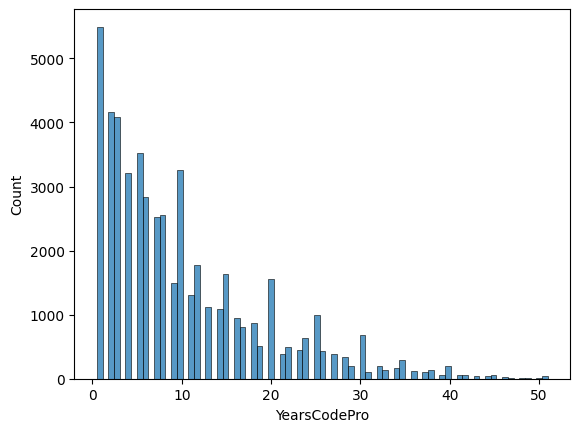

In [41]:
df_yearscodepro['YearsCodePro'] = (
    df_yearscodepro['YearsCodePro'].replace(
    {'Less than 1 year': 0.5,
     'More than 50 years': 51}
).astype(float)
)
sns.histplot(data=df_yearscodepro['YearsCodePro'].dropna())

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [54]:
## Write your code here
QUERY = "Select Age from main"

df_age = pd.read_sql(QUERY, conn)
df_age['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [64]:
comp_age_df = pd.DataFrame({'CompTotal': df_comp_total['CompTotal'].values, 'Age': df_age['Age'].values})
comp_age_df.dropna()

,CompTotal,Age
72,2040000.0,18-24 years old
374,28000.0,25-34 years old
379,85000.0,35-44 years old
385,50000.0,35-44 years old
389,110000.0,25-34 years old
...,...,...
65396,36000.0,18-24 years old
65401,40000.0,25-34 years old
65408,61000.0,25-34 years old
65412,58000.0,35-44 years old


Text(0, 0.5, 'Density')

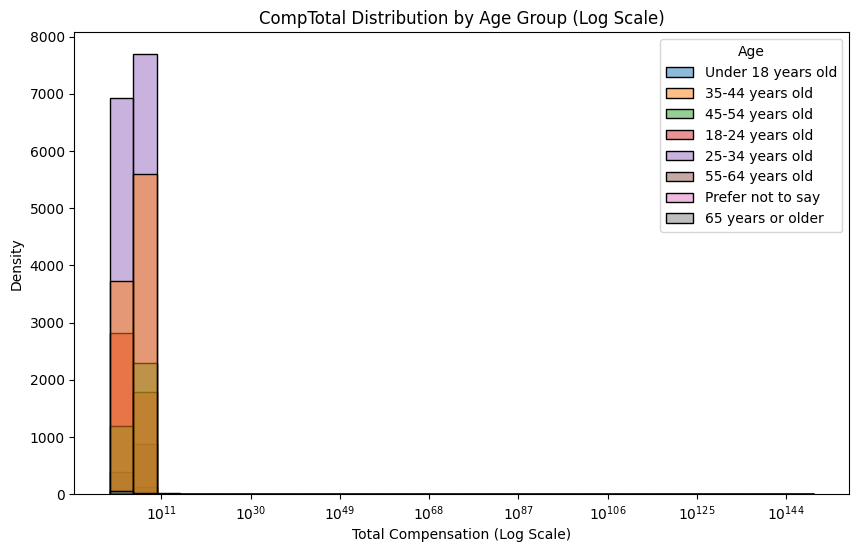

In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=comp_age_df,
    x='CompTotal',
    hue='Age',
    bins=30,
    log_scale=True,
)

plt.title('CompTotal Distribution by Age Group (Log Scale)')
plt.xlabel('Total Compensation (Log Scale)')
plt.ylabel('Density')

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [87]:
## Write your code here
QUERY = "SELECT Age, TimeSearching FROM main"
df_ts_age = pd.read_sql(QUERY, conn)

print(df_ts_age['Age'].unique())
print(df_ts_age['TimeSearching'].unique())

['Under 18 years old' '35-44 years old' '45-54 years old'
 '18-24 years old' '25-34 years old' '55-64 years old' 'Prefer not to say'
 '65 years or older']
[None '30-60 minutes a day' '60-120 minutes a day' '15-30 minutes a day'
 'Less than 15 minutes a day' 'Over 120 minutes a day']


In [92]:
time_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

df_ts_age['TimeSearching_min'] = df_ts_age['TimeSearching'].map(time_map)
df_ts_age['TimeSearching_min'].unique()

array([  nan,  45. ,  90. ,  22.5,   7.5, 150. ])

In [ ]:
df_ts_age = df_ts_age.dropna(subset=['Age', 'TimeSearching_min'])
df_ts_age = df_ts_age[df_ts_age['Age'] != 'Prefer not to say'] # filtering and dropping Prefer not to say rows
df_ts_age

,Age,TimeSearching,TimeSearching_min
10,35-44 years old,30-60 minutes a day,45.0
12,35-44 years old,30-60 minutes a day,45.0
15,45-54 years old,60-120 minutes a day,90.0
18,25-34 years old,15-30 minutes a day,22.5
20,25-34 years old,Less than 15 minutes a day,7.5
...,...,...,...
65261,18-24 years old,30-60 minutes a day,45.0
65265,18-24 years old,60-120 minutes a day,90.0
65268,25-34 years old,Less than 15 minutes a day,7.5
65351,25-34 years old,15-30 minutes a day,22.5


Text(0.5, 1.01, 'Distribution of Time Spent Searching for Information by Age Group')

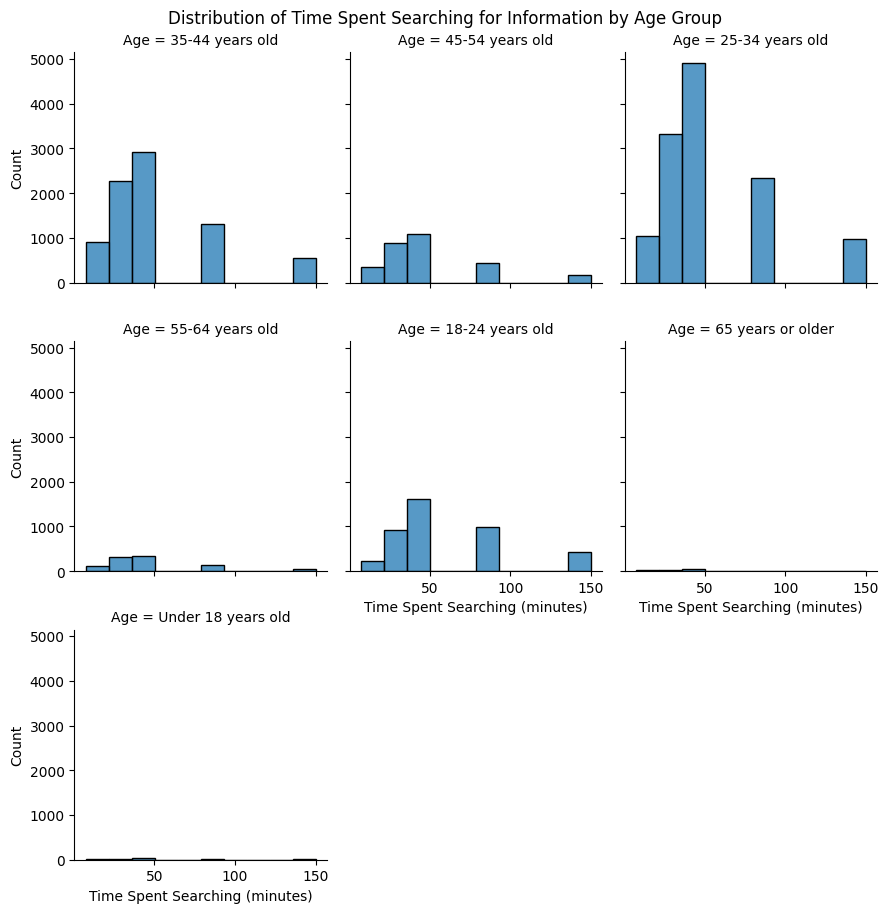

In [103]:
g = sns.FacetGrid(
    df_ts_age,
    col='Age',
    col_wrap=3,
    height=3,
    sharex=True,
    sharey=True
)

g.map(sns.histplot, 'TimeSearching_min', bins=10)
g.set_axis_labels('Time Spent Searching (minutes)', 'Count')
g.fig.suptitle(
    'Distribution of Time Spent Searching for Information by Age Group', y=1.01
)

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.

In [104]:
## Write your code here
query = "select DatabaseWantToWorkWith from main"
db_tw = pd.read_sql(query, conn)
db_tw['DatabaseWantToWorkWith'].unique()

array([None, 'PostgreSQL', 'Firebase Realtime Database', ...,
       'Cassandra;Firebase Realtime Database;MariaDB;Microsoft Access;MongoDB;MySQL;PostgreSQL;Redis',
       'MySQL;Presto;TiDB',
       'BigQuery;Cassandra;Databricks SQL;DuckDB;Elasticsearch;Firebase Realtime Database;Microsoft SQL Server;MongoDB;MySQL;PostgreSQL;Redis;Snowflake;SQLite;Supabase'],
      shape=(8479,), dtype=object)

In [ ]:
#db_tw = db_tw['DatabaseWantToWorkWith'].str.split(';').explode().dropna()
top5_dbtw = db_tw.value_counts().head()
top5_dbtw

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

Text(0, 0.5, 'Number of Respondents')

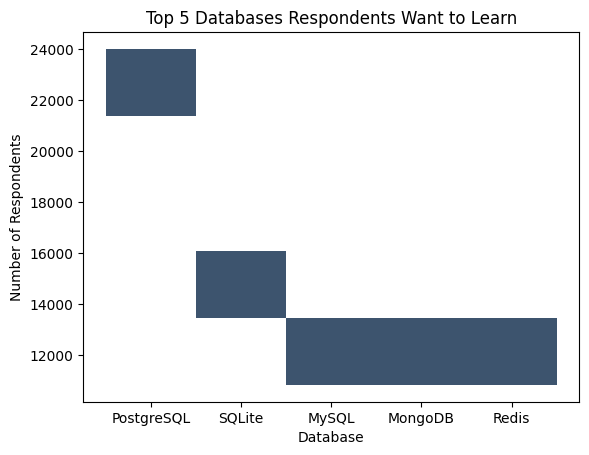

In [115]:
sns.histplot(x=top5_dbtw.index, y=top5_dbtw.values)
plt.title("Top 5 Databases Respondents Want to Learn")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [117]:
## Write your code here
query = "select RemoteWork from main"
df_rw = pd.read_sql(query, conn)
df_rw['RemoteWork'].unique()

array(['Remote', None, 'In-person',
       'Hybrid (some remote, some in-person)'], dtype=object)

In [118]:
df_rw = df_rw['RemoteWork'].dropna()
df_rw

0                                      Remote
1                                      Remote
2                                      Remote
6                                      Remote
8                                   In-person
                         ...                 
65431    Hybrid (some remote, some in-person)
65432                                  Remote
65433                                  Remote
65434                               In-person
65435    Hybrid (some remote, some in-person)
Name: RemoteWork, Length: 54806, dtype: object

Text(0.5, 1.0, 'Distribution of Preferred Work Arrangements (Remote Work)')

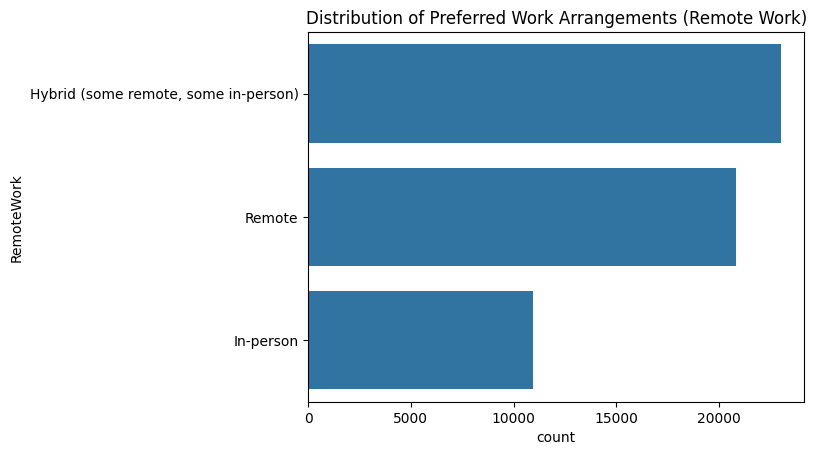

In [ ]:
sns.countplot(y=df_rw, order=df_rw.value_counts().index) # Categorical Values
plt.title('Distribution of Preferred Work Arrangements (Remote Work)')

In [121]:
encoding = {
    'In-person': 0,
    'Hybrid (some remote, some in-person)': 1,
    'Remote': 2
}

df_rw_encoded = df_rw.map(encoding)

Text(0.5, 1.0, 'Distribution of Preferred Work Arrangements (Encoded)')

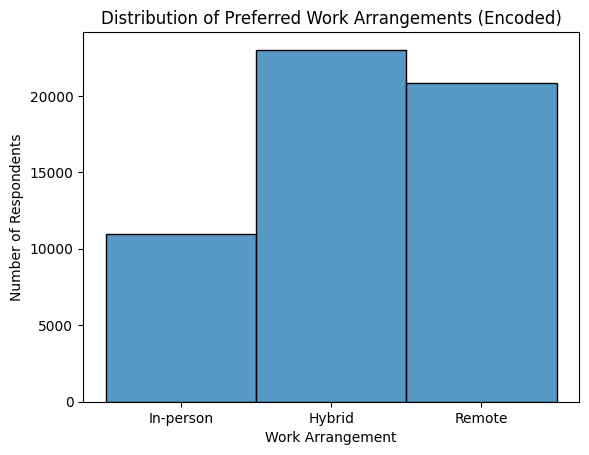

In [124]:
sns.histplot(df_rw_encoded, bins=[-0.5, 0.5, 1.5, 2.5])
plt.xticks([0,1,2], ['In-person', 'Hybrid', 'Remote'])
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Preferred Work Arrangements (Encoded)')

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [130]:
## Write your code here
query = "select Age, CompTotal from main"
df_ct = pd.read_sql(query, conn)
df_ct['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [136]:
age_group = df_ct[
    df_ct['Age'].isin(['45-54 years old', '55-64 years old'])
].dropna(subset=['CompTotal'])
age_group

,Age,CompTotal
395,45-54 years old,95000.0
398,45-54 years old,195000.0
409,55-64 years old,54000.0
414,45-54 years old,145000.0
424,55-64 years old,80000.0
...,...,...
65178,45-54 years old,40000.0
65247,45-54 years old,250000.0
65269,45-54 years old,250000.0
65270,45-54 years old,157000.0


Text(0, 0.5, 'Number of Respondents')

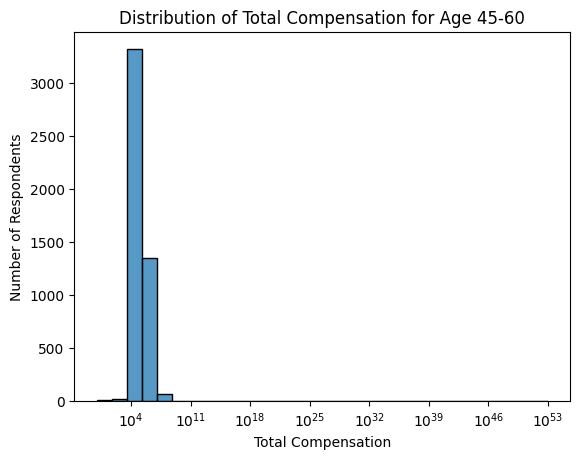

In [143]:
sns.histplot(age_group['CompTotal'], bins=30, log_scale=(True, False)) # sns.histplot(x='CompTotal', data=age_group, bins=30)
plt.title('Distribution of Total Compensation for Age 45-60')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [144]:
## Write your code here
query = 'select JobSat, YearsCodePro from main'
df_js_ycp = pd.read_sql(query, conn)
df_js_ycp

,JobSat,YearsCodePro
0,NaN,None
1,NaN,17
2,NaN,27
3,NaN,None
4,NaN,None
...,...,...
65432,NaN,3
65433,NaN,None
65434,NaN,5
65435,NaN,2


In [148]:
print(df_js_ycp['YearsCodePro'].unique())
print('-------------')
print(df_js_ycp['JobSat'].unique())

[None '17' '27' '7' '11' '25' '12' '10' '3' 'Less than 1 year' '18' '37'
 '15' '20' '6' '2' '16' '8' '14' '4' '45' '1' '24' '29' '5' '30' '26' '9'
 '33' '13' '35' '23' '22' '31' '19' '21' '28' '34' '32' '40' '50' '39'
 '44' '42' '41' '36' '38' 'More than 50 years' '43' '47' '48' '46' '49']
-------------
[nan  8.  5. 10.  6.  9.  4.  7.  3.  2.  1.  0.]


In [150]:
year_map = {
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}

df_js_ycp['YearsCodePro'] = df['YearsCodePro'].replace(year_map).astype(float)
df_js_ycp['YearsCodePro'].unique()

array([ nan, 17. , 27. ,  7. , 11. , 25. , 12. , 10. ,  3. ,  0.5, 18. ,
       37. , 15. , 20. ,  6. ,  2. , 16. ,  8. , 14. ,  4. , 45. ,  1. ,
       24. , 29. ,  5. , 30. , 26. ,  9. , 33. , 13. , 35. , 23. , 22. ,
       31. , 19. , 21. , 28. , 34. , 32. , 40. , 50. , 39. , 44. , 42. ,
       41. , 36. , 38. , 51. , 43. , 47. , 48. , 46. , 49. ])

In [154]:
df_js_ycp = df_js_ycp.dropna(subset=['JobSat', 'YearsCodePro'])
df_js_ycp.head()

,JobSat,YearsCodePro
12,8.0,12.0
15,5.0,27.0
18,10.0,10.0
20,6.0,0.5
22,9.0,18.0


Text(0, 0.5, 'Number of Respondents')

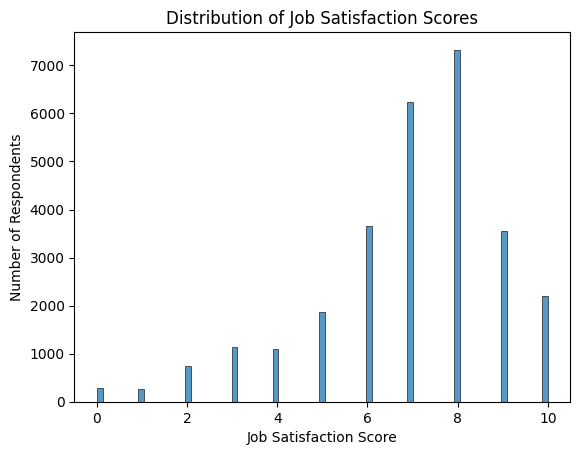

In [158]:
sns.histplot(df_js_ycp['JobSat'])
plt.title('Distribution of Job Satisfaction Scores')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Number of Respondents')

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [159]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
